
实验: Exp1: Tickets 8:4:2:1
理想分配比例: A=53.3%, B=26.7%, C=13.3%, D=6.7%

在100 ticks时的结果对比:
----------------------------------------------------------------------
Lottery调度器:
  A: 53 ticks (53.0%) | 理想: 53 | 误差: 0.6%
  B: 27 ticks (27.0%) | 理想: 27 | 误差: 1.3%
  C: 13 ticks (13.0%) | 理想: 13 | 误差: 2.5%
  D: 7 ticks (7.0%) | 理想: 7 | 误差: 5.0%

Stride调度器:
  A: 53 ticks (53.0%) | 理想: 53 | 误差: 0.6%
  B: 27 ticks (27.0%) | 理想: 27 | 误差: 1.3%
  C: 13 ticks (13.0%) | 理想: 13 | 误差: 2.5%
  D: 7 ticks (7.0%) | 理想: 7 | 误差: 5.0%

实验: Exp2: Tickets 1:1:1:1
理想分配比例: A=25.0%, B=25.0%, C=25.0%, D=25.0%

在100 ticks时的结果对比:
----------------------------------------------------------------------
Lottery调度器:
  A: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  B: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  C: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  D: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%

Stride调度器:
  A: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  B: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  C: 25 ticks (25.0%) | 理想: 25 | 误差: 0.0%
  D: 25 t

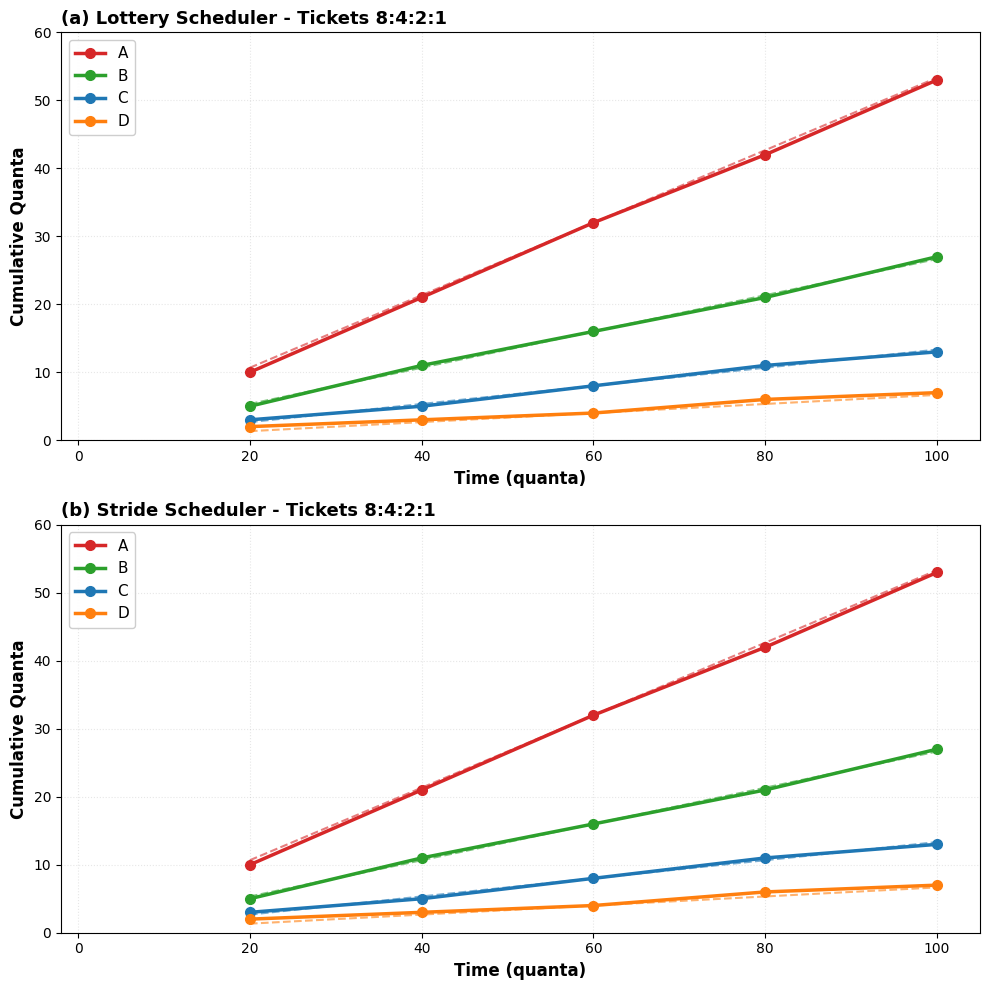

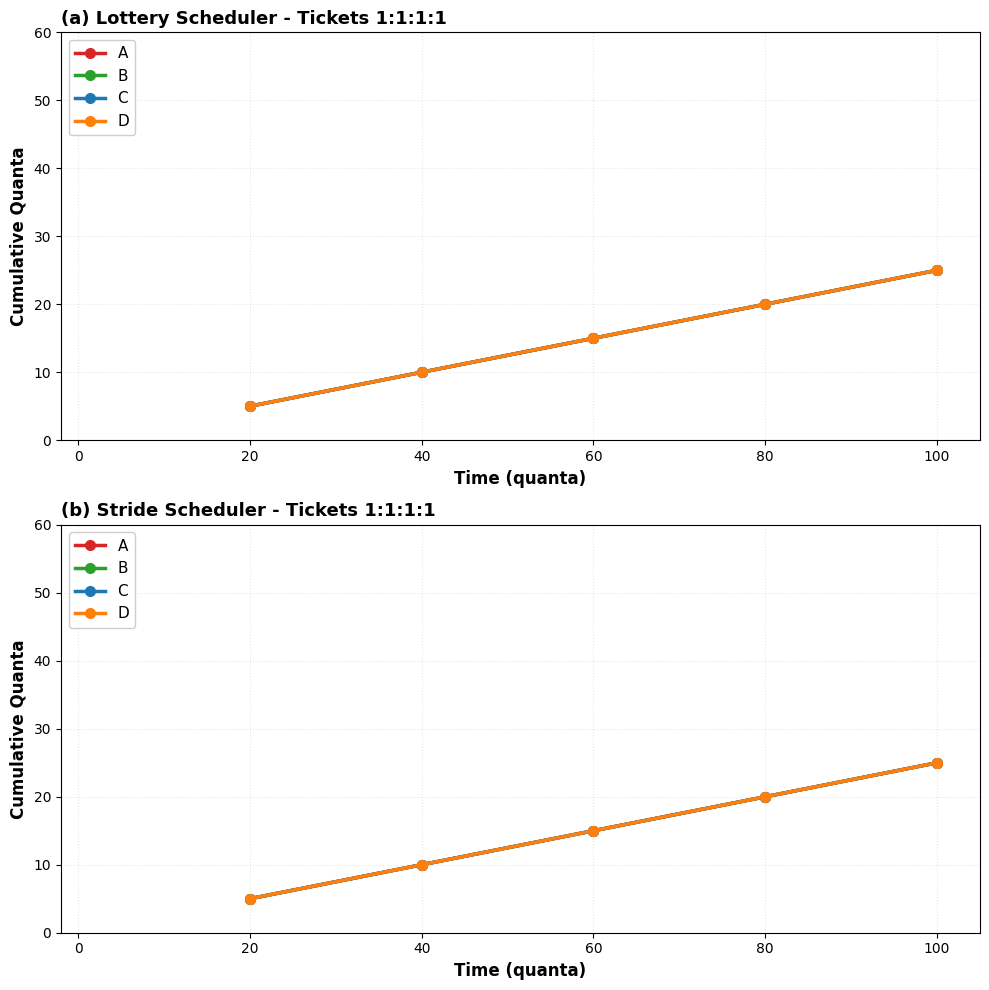


✓ 所有图表已生成完成！


In [1]:

import matplotlib.pyplot as plt
import numpy as np

# ==================== 数据提取和处理 ====================

time_points = [20, 40, 60, 80, 100]

# ===== LOTTERY 数据 (第一次编译运行) =====
lottery_exp1_data = {
    20: [10, 5, 3, 2],
    40: [21, 11, 5, 3],
    60: [32, 16, 8, 4],
    80: [42, 21, 11, 6],
    100: [53, 27, 13, 7],
}

lottery_exp2_data = {
    20: [5, 5, 5, 5],
    40: [10, 10, 10, 10],
    60: [15, 15, 15, 15],
    80: [20, 20, 20, 20],
    100: [25, 25, 25, 25],
}

# ===== STRIDE 数据 (第二次编译运行，从"退出来"后的部分提取) =====
stride_exp1_data = {
    20: [10, 5, 3, 2],
    40: [21, 11, 5, 3],
    60: [32, 16, 8, 4],
    80: [42, 21, 11, 6],
    100: [53, 27, 13, 7],
}

stride_exp2_data = {
    20: [5, 5, 5, 5],
    40: [10, 10, 10, 10],
    60: [15, 15, 15, 15],
    80: [20, 20, 20, 20],
    100: [25, 25, 25, 25],
}

# 转换格式
def data_to_dict(data_dict):
    result = {
        'A': [data_dict[t][0] for t in time_points],
        'B': [data_dict[t][1] for t in time_points],
        'C': [data_dict[t][2] for t in time_points],
        'D': [data_dict[t][3] for t in time_points],
    }
    return result

lottery_exp1 = data_to_dict(lottery_exp1_data)
lottery_exp2 = data_to_dict(lottery_exp2_data)
stride_exp1 = data_to_dict(stride_exp1_data)
stride_exp2 = data_to_dict(stride_exp2_data)

# ==================== 理想分配计算 ====================

def calculate_ideal(tickets, time_points):
    total = sum(tickets)
    labels = ['A', 'B', 'C', 'D']
    ideal = {label: [] for label in labels}
    
    for label, ticket in zip(labels, tickets):
        ideal[label] = [t * ticket / total for t in time_points]
    
    return ideal

ideal_exp1 = calculate_ideal([8, 4, 2, 1], time_points)
ideal_exp2 = calculate_ideal([1, 1, 1, 1], time_points)

# ==================== 数据验证和分析 ====================

def analyze_results(lottery, stride, ideal, config_name, tickets):
    """分析实验结果"""
    print(f"\n{'='*70}")
    print(f"实验: {config_name}")
    print(f"{'='*70}")
    
    total_tickets = sum(tickets)
    ideal_ratios = [t/total_tickets for t in tickets]
    
    print(f"理想分配比例: A={ideal_ratios[0]:.1%}, B={ideal_ratios[1]:.1%}, "
          f"C={ideal_ratios[2]:.1%}, D={ideal_ratios[3]:.1%}")
    
    # 在100 ticks时的分析
    print(f"\n在100 ticks时的结果对比:")
    print("-" * 70)
    
    labels = ['A', 'B', 'C', 'D']
    
    print("Lottery调度器:")
    lottery_total = sum([lottery[l][-1] for l in labels])
    for i, label in enumerate(labels):
        actual = lottery[label][-1]
        ideal_val = ideal[label][-1]
        ratio = actual / lottery_total if lottery_total > 0 else 0
        error = abs(ratio - ideal_ratios[i]) / ideal_ratios[i] * 100
        print(f"  {label}: {actual:.0f} ticks ({ratio:.1%}) | 理想: {ideal_val:.0f} | 误差: {error:.1f}%")
    
    print("\nStride调度器:")
    stride_total = sum([stride[l][-1] for l in labels])
    for i, label in enumerate(labels):
        actual = stride[label][-1]
        ideal_val = ideal[label][-1]
        ratio = actual / stride_total if stride_total > 0 else 0
        error = abs(ratio - ideal_ratios[i]) / ideal_ratios[i] * 100
        print(f"  {label}: {actual:.0f} ticks ({ratio:.1%}) | 理想: {ideal_val:.0f} | 误差: {error:.1f}%")

# 执行分析
analyze_results(lottery_exp1, stride_exp1, ideal_exp1, "Exp1: Tickets 8:4:2:1", [8, 4, 2, 1])
analyze_results(lottery_exp2, stride_exp2, ideal_exp2, "Exp2: Tickets 1:1:1:1", [1, 1, 1, 1])

# ==================== 绘图 ====================

def plot_experiment(lottery_data, stride_data, ideal_data, time_points, config, filename):
    """绘制对比图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    colors = {'A': '#D62728', 'B': '#2CA02C', 'C': '#1F77B4', 'D': '#FF7F0E'}
    labels = ['A', 'B', 'C', 'D']
    
    # ===== 上图: Lottery Scheduler =====
    for label in labels:
        ax1.plot(time_points, lottery_data[label], 
                color=colors[label], marker='o', linestyle='-', 
                linewidth=2.5, markersize=7, label=label, zorder=3)
        ax1.plot(time_points, ideal_data[label], 
                color=colors[label], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
    
    ax1.set_xlabel('Time (quanta)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cumulative Quanta', fontsize=12, fontweight='bold')
    ax1.set_title(f'(a) Lottery Scheduler - {config}', fontsize=13, fontweight='bold', loc='left')
    ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax1.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax1.set_xlim(-2, 105)
    ax1.set_ylim(0, max(time_points) * 0.6)
    
    # ===== 下图: Stride Scheduler =====
    for label in labels:
        ax2.plot(time_points, stride_data[label], 
                color=colors[label], marker='o', linestyle='-', 
                linewidth=2.5, markersize=7, label=label, zorder=3)
        ax2.plot(time_points, ideal_data[label], 
                color=colors[label], linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
    
    ax2.set_xlabel('Time (quanta)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Cumulative Quanta', fontsize=12, fontweight='bold')
    ax2.set_title(f'(b) Stride Scheduler - {config}', fontsize=13, fontweight='bold', loc='left')
    ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax2.legend(loc='upper left', fontsize=11, framealpha=0.95)
    ax2.set_xlim(-2, 105)
    ax2.set_ylim(0, max(time_points) * 0.6)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n✓ 已保存: {filename}")
    return fig

# 生成两个实验的图表
print("\n生成图表中...")
plot_experiment(lottery_exp1, stride_exp1, ideal_exp1, time_points, 
               'Tickets 8:4:2:1', 'experiment1_8421.png')
plot_experiment(lottery_exp2, stride_exp2, ideal_exp2, time_points, 
               'Tickets 1:1:1:1', 'experiment2_1111.png')

plt.show()

print("\n" + "="*70)
print("✓ 所有图表已生成完成！")
print("="*70)